Breast Cancer Prediction Using Machine Learning

The dataset contains 569 rows and 33 columns. I am Predicting whether the tumour is cancerous(m - malignant) or non cancerous(B- Benign) using the features in the dataset.
id - Unique identification of the tumor/sample
diagnosis - Target: M/B
radius_mean - Average radius of the tumour
texture_mean  Average texture of the tumour 
perimeter_mean - Average perimeter around the tumour
area_mean - Average area of the tumour
smoothness_mean - Average smoothness of the tumour boundary
compactness_mean - Average compactness of the tumour
concavity_mean - Average concavity/inward curves of the tumour
concave points_mean - Average number/severity of concave points
symmetry_mean - Average symmetry of the tumor
fractal_dimension_mean - Average complexity of the tumor boundary
radius_se - Standard error of radius
texture_se - Standard error of texture
perimeter_se - Standard error of perimeter
area_se - Standard error of area
smoothness_se - Standard error of smoothness
compactness_se - Standard error of compactness
concavity_se - Standard error of concavity
concave points_se - Standard error of concave points
symmetry_se - Standard error of symmetry
fractal_dimension_se - Standard error of fractal dimension
radius_worst - Largest/worst radius measurement
texture_worst - Largest/worst texture measurement
perimeter_worst - Largest/worst perimeter measurement
area_worst	Largest/worst area measurement
smoothness_worst	Largest/worst smoothness measurement
compactness_worst	Largest/worst compactness measurement
concavity_worst	Largest/worst concavity measurement
concave points_worst	Largest/worst concave-point measurement
symmetry_worst	Largest/worst symmetry measurement
fractal_dimension_worst	Largest/worst fractal-dimension measurement


In [38]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [9]:
data = pd.read_csv(r'C:\Users\POOJA\Downloads\data.csv')
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [10]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [11]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [12]:
print(data.describe())

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

In [13]:
data.shape

(569, 33)

In [14]:
print(data.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

The unknown column is entirely consists of missing value, so removing it. Id column is not useful to the predictio, so removing it.

In [18]:
data.drop(['id','Unnamed: 32'],axis = 1, inplace = True)

In [19]:
print(data.duplicated().sum())

0


There are no duplicate values in the dataset

Label encoding

In [22]:
le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [24]:
x = data.drop(['diagnosis'], axis = 1)
y = data['diagnosis']

Splitting the daatset

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42, stratify = y)

In [29]:
model = RandomForestClassifier(n_estimators = 100, random_state = 42)
model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [30]:
y_pred = model.predict(x_test)

In [ ]:
print('accuracy', accuracy_score(y_test, y_pred))

accuracy 0.9736842105263158


In [35]:
print('confusion_matrix\n', confusion_matrix(y_test, y_pred))

confusion_matrix
 [[72  0]
 [ 3 39]]


B(0) - 72 predictions are correct
M(1) - 39 prediction are correct, 3 predictions were predicted as B

In [36]:
print('classification_report', classification_report(y_test, y_pred))

classification_report               precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



Feature importance

In [37]:
feature_importance = pd.Series(model.feature_importances_, index = x.columns).sort_values(ascending = False)
print(feature_importance)

area_worst                 0.151412
concave points_worst       0.126497
radius_worst               0.093475
perimeter_worst            0.083642
concave points_mean        0.081082
perimeter_mean             0.077126
radius_mean                0.061990
concavity_mean             0.050818
area_mean                  0.045916
concavity_worst            0.030022
area_se                    0.029064
compactness_worst          0.018005
texture_worst              0.016174
texture_mean               0.015545
smoothness_worst           0.015093
radius_se                  0.014503
symmetry_worst             0.013301
compactness_mean           0.012218
perimeter_se               0.012037
fractal_dimension_se       0.006592
concavity_se               0.006083
compactness_se             0.005929
symmetry_mean              0.005097
fractal_dimension_worst    0.004887
texture_se                 0.004436
smoothness_mean            0.004349
symmetry_se                0.004242
fractal_dimension_mean     0

The most important one needed for measuring the danger of the tumour is area/spread of the tumour, whereas the least one effecting is the Standarad error of smoothness

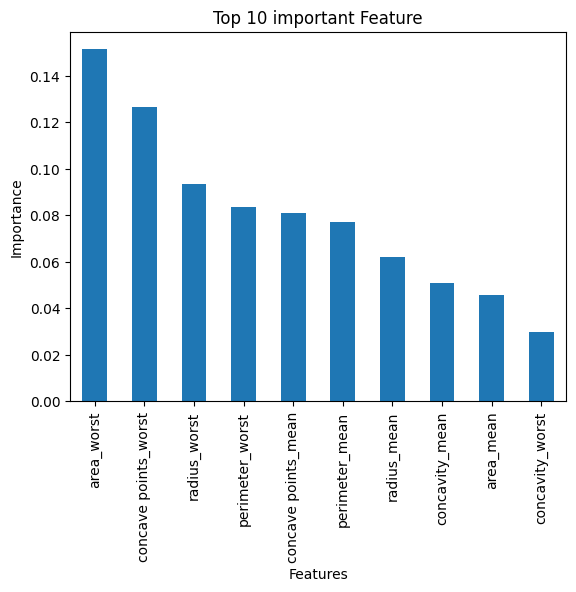

In [39]:
feature_importance.head(10).plot(kind = 'bar')
plt.title('Top 10 important Feature')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

In [42]:
new_data = [[14.0, 20, 90, 600, 0.1, 0.1, 0.08, 0.05, 0.18, 0.06, 0.05, 1, 3 ,40, 0.01, 0.02, 0.01, 0.02, 0.003, 16, 25, 105, 800, 0.13, 0.2, 0.25, 0.1, 0.25, 0.08, 0.07]]
new_data_ = pd.DataFrame(new_data, columns = x. columns)
r_f = model.predict(new_data_)[0]
print('The Patient is Diagnosed with', le.inverse_transform([r_f])[0])

The Patient is Diagnosed with M
